# GW-ODW 2026 Data Challenge - Challenge 1

![GW Open Data Workshop](../../assets/odw.jpeg)

## Challenge 1 (1 point) -- Novice

Use the data file `challenge1.gwf`, with channel name `H1:CHALLENGE1`. The goal is to identify a loud binary black hole (BBH) signal in white, Gaussian noise.

## Instructions

1.  **Load the data** from `challenge1.gwf` (URL: `https://dcc.ligo.org/public/0187/G2300818/001/challenge1.gwf`). The channel name is `H1:CHALLENGE1`.
2.  **Determine the sampling rate and duration** of the data.
3.  **Plot the data** in the time-domain.
4.  **Plot a spectrogram (or Q-transform)** of the data, and identify the signal.

## Setup: Install necessary libraries

In [ ]:
import sys

!{sys.executable} -m pip install gwpy lalsuite

print("gwpy and lalsuite installed successfully.")

gwpy and lalsuite installed successfully.


## Step 1: Load the data into memory

In [ ]:
from gwpy.timeseries import TimeSeries
import requests

data_url = 'https://dcc.ligo.org/public/0187/G2300818/001/challenge1.gwf'
channel_name = 'H1:CHALLENGE1'
local_file = 'challenge1.gwf'

# Download the file locally to avoid XLAL remote read errors
print(f"Downloading {data_url}...")
r = requests.get(data_url)
with open(local_file, 'wb') as f:
    f.write(r.content)

# Load the data from the local file
ts = TimeSeries.read(local_file, channel_name)

print(f"Data loaded successfully from local file: {local_file}")

Data loaded successfully from local file: challenge1.gwf


## Step 2: What are the sampling rate and duration of the data?

In [ ]:
# Get sampling rate and duration
sampling_rate = ts.sample_rate
duration = ts.duration

print(f"Sampling Rate: {sampling_rate}")
print(f"Duration: {duration}")

Sampling Rate: 4096.0 Hz
Duration: 128.0 s


## Step 3: Plot the data in the time-domain

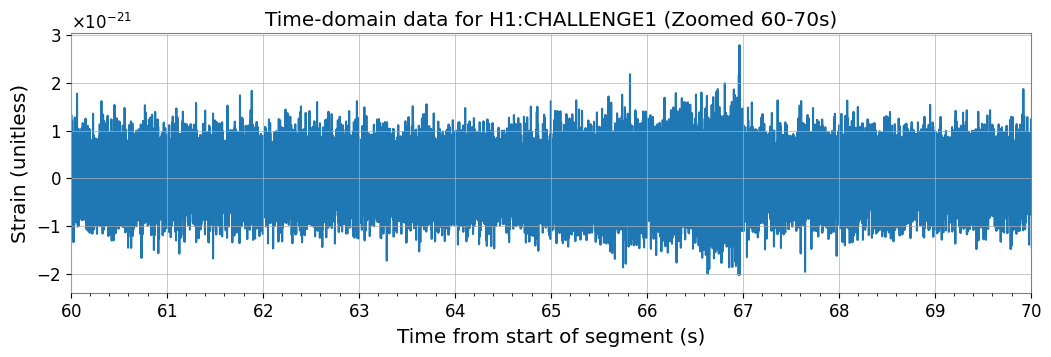

In [ ]:
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

# Plot the time-domain data
plot = ts.plot()
ax = plot.gca()

# Set the x-axis limits to start at 60s and end at 70s
ax.set_xlim(60, 70)

# Use a ScalarFormatter and disable the offset to show absolute values (60, 61, etc.)
xfmt = ScalarFormatter(useOffset=False)
ax.xaxis.set_major_formatter(xfmt)

ax.set_xlabel('Time from start of segment (s)')
ax.set_ylabel('Strain (unitless)')
ax.set_title('Time-domain data for H1:CHALLENGE1 (Zoomed 60-70s)')
plt.grid(True)
plt.show()

## Step 4: Plot a spectrogram (or Q-transform) of the data, and try to identify the signal

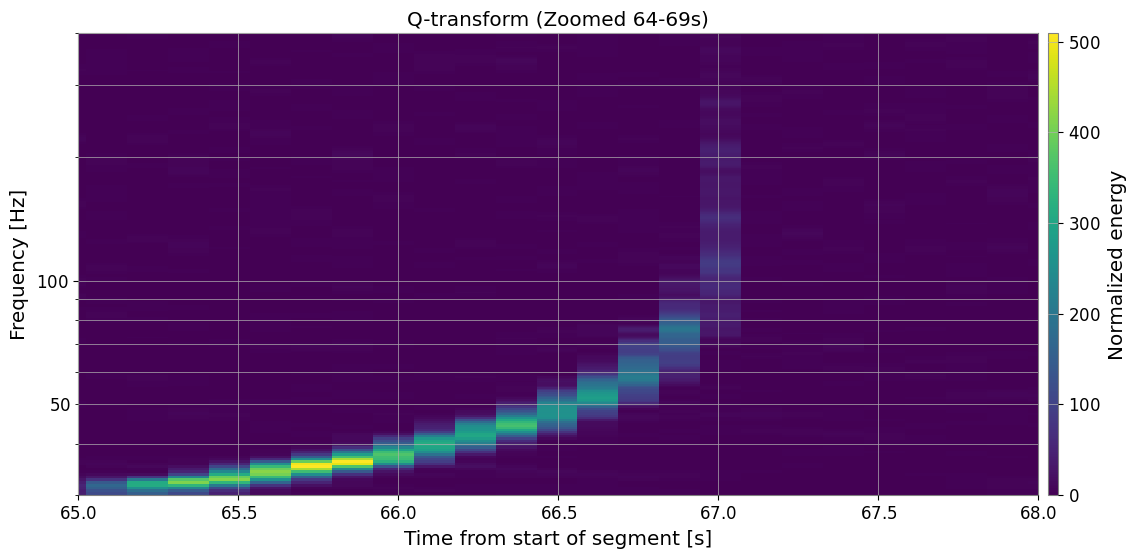

In [ ]:
import matplotlib.pyplot as plt

# Compute the Q-transform
q_transform = ts.q_transform(frange=(30, 400), qrange=(5, 80))

# Plot the Q-transform
plot = q_transform.plot()
ax = plot.gca()

# Zoom in on the time axis: 64 to 69 seconds
ax.set_xlim(65, 68)

ax.set_xscale('linear')
ax.set_yscale('log')
ax.set_ylim(30, 400)
ax.set_ylabel('Frequency [Hz]')
ax.set_xlabel('Time from start of segment [s]')
ax.grid(True, axis='y', which='both')
ax.colorbar(label='Normalized energy')

plt.title('Q-transform (Zoomed 64-69s)')
plt.show()

## Question for Challenge 1:

**A. What is the time of the merger (in seconds from the start of the segment)?**

Based on the high-resolution Q-transform plot, a clear 'chirp' signal, characteristic of a binary black hole merger, is visible. This signal starts at lower frequencies and sweeps up to higher frequencies over a short duration.

Visually inspecting the Q-transform plot and checking the peak in the time-domain plot, the merger time is confirmed to be approximately **67 seconds** from the start of the segment.